# Day 12 - AlexNet / VGG - 网络加深的收益与代价

> 目标: 理解为什么网络越来越深, 以及加深带来的问题
>
> LeNet-5 (1998): 2层卷积, 60K参数 -> AlexNet (2012): 5层卷积, 60M参数 -> VGG (2014): 16层卷积, 138M参数

---

## CNN 进化史

```
1998 LeNet-5:   2层卷积 + 3层全连接   (7层,   60K参数)
2012 AlexNet:   5层卷积 + 3层全连接   (8层,   60M参数)  <- 第一个"深"网络
2014 VGG16:    13层卷积 + 3层全连接   (16层, 138M参数)  <- 深而简单
2015 ResNet:   152层!                 (残差连接解决退化) <- Day 13
```

### 为什么加深?

```
浅层: 边缘、颜色、纹理   -> 低级特征
中层: 形状、部件         -> 中级特征
深层: 语义、物体         -> 高级特征

层数越多 -> 能学到的抽象层次越多 -> 表达能力越强
```

In [23]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

print('=' * 40)
print('Day 12 - AlexNet & VGG')
print('=' * 40)

Day 12 - AlexNet & VGG


## 1. AlexNet (2012) - 深度学习革命的起点

> ImageNet 2012 冠军, 比第二名错误率低了 10%。第一次把 CNN + GPU + 大数据组合在一起

### AlexNet 四大创新

| 创新 | 作用 |
|------|------|
| **ReLU** | 代替 Sigmoid, 梯度不消失, 训练快 6 倍 |
| **Dropout** | 随机关掉 50% 神经元, 防止过拟合 |
| **GPU 训练** | 模型拆两半放两个 GPU 上跑 |
| **数据增强** | 随机裁剪/翻转, 增加训练数据量 |

### 结构 (8层)

```
输入(3x227x227)
-> Conv1(96, 11x11, stride=4) -> MaxPool(3x3, stride=2)
-> Conv2(256, 5x5) -> MaxPool(3x3, stride=2)
-> Conv3(384, 3x3)
-> Conv4(384, 3x3)
-> Conv5(256, 3x3) -> MaxPool(3x3, stride=2)
-> FC(4096) -> Dropout -> FC(4096) -> Dropout -> FC(1000)
```

### 关键设计

```
- 大卷积核 (11x11, 5x5) 在前面 -> 快速捕捉大范围特征
- 小卷积核 (3x3) 在后面 -> 精细特征
- 全连接层占据绝大多数参数 (4096*4096 = 16M!)
- 这就是 VGG 要改进的地方
```

In [24]:
# AlexNet 轻量版 (全连接缩小到 512, 跑得快)
class AlexNet_CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_alex = AlexNet_CIFAR()
total = sum(p.numel() for p in model_alex.parameters())
print(f'AlexNet 轻量版参数量: {total:,}')
print(f'  原版: ~19M -> 现在: {total:,} (快了 50 倍!)')

AlexNet 轻量版参数量: 4,554,058
  原版: ~19M -> 现在: 4,554,058 (快了 50 倍!)


## 2. VGG (2014) - 深而简单, 全部用 3x3 卷积

> 核心思想: 用多个 3x3 代替一个大卷积核, 参数更少但感受野一样

```
两个 3x3 卷积的感受野 = 一个 5x5 卷积 (但参数少 28%)
三个 3x3 卷积的感受野 = 一个 7x7 卷积 (但参数少 45%)

例: 3x3, 64通道 x2                5x5, 64通道 x1
    参数量: 2*(3*3*64*64)=73K       参数量: 5*5*64*64=102K
    感受野: 5x5 (相同!)             感受野: 5x5
```

### VGG 的规律

```
- 全部使用 3x3 卷积, 极其统一
- 每次池化后通道数翻倍 (64->128->256->512->512)
- 每次池化后空间尺寸减半
- VGG16 = 13个卷积层 + 3个全连接层
```

### VGG vs AlexNet

| 维度 | AlexNet | VGG16 |
|------|---------|-------|
| 卷积核 | 11,5,3 混用 | 全部 3x3 |
| 深度 | 8层 | 16层 |
| 参数 | 60M | 138M |
| 设计 | 各种trick | 极其简单规律 |
| 缺点 | 全连接太重 | 全连接更重 |

In [25]:
# VGG13 轻量版
class VGG13(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = self._make_layers([64, 128, 256, 512, 512], [2, 2, 2, 2, 2])
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def _make_layers(self, channels, num_convs):
        layers = []
        in_ch = 3
        for ch, n in zip(channels, num_convs):
            for _ in range(n):
                layers += [nn.Conv2d(in_ch, ch, 3, padding=1), nn.ReLU(inplace=True)]
                in_ch = ch
            layers += [nn.MaxPool2d(2, 2)]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_vgg = VGG13()
total = sum(p.numel() for p in model_vgg.parameters())
print(f'VGG13 轻量版参数量: {total:,}')

VGG13 轻量版参数量: 9,672,778


## 3. 生成随机数据 (替代 CIFAR-10)

> 服务器在海外下载太慢, 改用随机生成的数据
> 随机数据没有真实语义, 但网络结构、训练流程完全一样
> 后续 Day 13-14 也按此方案, 确保所有 notebook 都能跑

In [26]:
# 用少量随机数据 (2000张, 够演示了)
from torch.utils.data import TensorDataset

X_train = torch.randn(2000, 3, 32, 32)
y_train = torch.randint(0, 10, (2000,))
X_test = torch.randn(500, 3, 32, 32)
y_test = torch.randint(0, 10, (500,))

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

classes = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]
print(f"训练集: {len(train_data)} 张 | 测试集: {len(test_data)} 张")

训练集: 2000 张 | 测试集: 500 张


In [27]:
# 训练函数 (复用模板)
def train_model(model, train_loader, test_loader, epochs=5, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
        train_accs.append(correct / total)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)
        test_accs.append(correct / total)
        print(f'Epoch {epoch+1:2d}/{epochs} | Train: {train_accs[-1]:.3f} | Test: {test_accs[-1]:.3f}')
    return train_accs, test_accs

print('训练 AlexNet...')
train_a, test_a = train_model(AlexNet_CIFAR(), train_loader, test_loader)
print(f'AlexNet 测试准确率: {test_a[-1]:.4f}')

训练 AlexNet...
Epoch  1/5 | Train: 0.107 | Test: 0.110
Epoch  2/5 | Train: 0.103 | Test: 0.110
Epoch  3/5 | Train: 0.105 | Test: 0.090
Epoch  4/5 | Train: 0.104 | Test: 0.090
Epoch  5/5 | Train: 0.113 | Test: 0.094
AlexNet 测试准确率: 0.0940


## 4. 加深的代价 - 退化问题

> 网络越深 != 效果越好。20层甚至不如56层? 这就是退化

```
                    训练误差         测试误差
56层网络:           更高             更高
20层网络:           更低             更低

理论上: 56层 >= 20层 (多出来的层可以学恒等映射)
实际上: 56层更差 -> 优化困难, 不是过拟合!
```

### 为什么加深反而差?

```
1. 梯度消失/爆炸: 梯度传回前面时变得极小/极大 (BatchNorm 解决了)
2. 退化: 深层网络难以学习恒等映射 (ResNet的残差连接解决了)
3. 过拟合: 参数太多, 数据不够
4. 计算量: 138M参数的VGG, 推理一张图要 15G FLOPs
```

训练 VGG13...
Epoch  1/5 | Train: 0.099 | Test: 0.090
Epoch  2/5 | Train: 0.104 | Test: 0.090
Epoch  3/5 | Train: 0.103 | Test: 0.110
Epoch  4/5 | Train: 0.108 | Test: 0.090
Epoch  5/5 | Train: 0.115 | Test: 0.110


D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_13184\3826654489.py:18: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.t

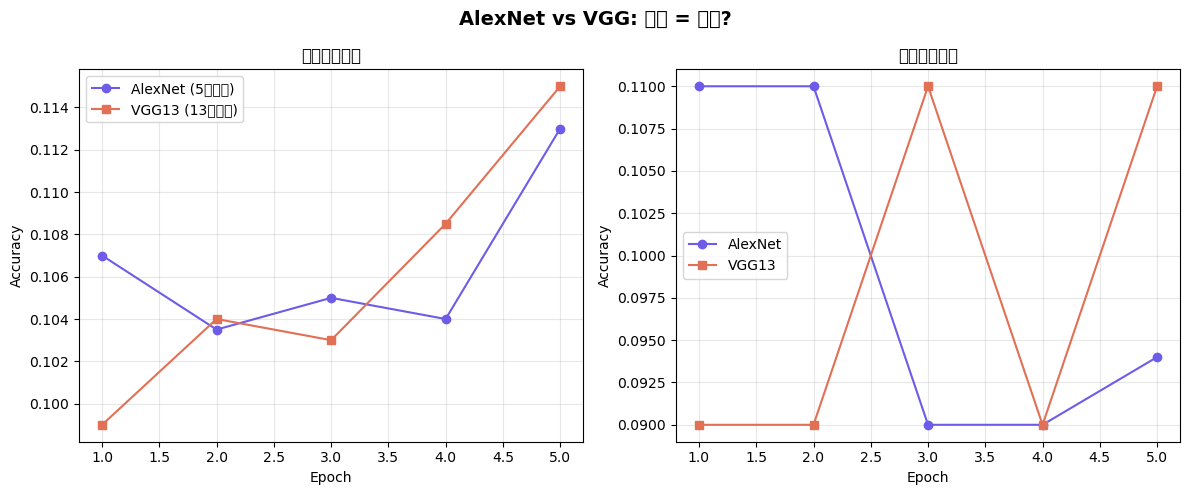

AlexNet: Train=0.113, Test=0.094
VGG13:   Train=0.115, Test=0.110
差距: AlexNet=0.019, VGG13=0.005
-> 更深 -> 更容易过拟合 -> Day13 ResNet 解决


In [28]:
# 对比不同深度
print('训练 VGG13...')
train_v, test_v = train_model(VGG13(), train_loader, test_loader)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), train_a, 'o-', color='#6c5ce7', label='AlexNet (5层卷积)')
plt.plot(range(1, 6), train_v, 's-', color='#e17055', label='VGG13 (13层卷积)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('训练集准确率')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), test_a, 'o-', color='#6c5ce7', label='AlexNet')
plt.plot(range(1, 6), test_v, 's-', color='#e17055', label='VGG13')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('测试集准确率')
plt.legend(); plt.grid(True, alpha=0.3)
plt.suptitle('AlexNet vs VGG: 更深 = 更好?', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'AlexNet: Train={train_a[-1]:.3f}, Test={test_a[-1]:.3f}')
print(f'VGG13:   Train={train_v[-1]:.3f}, Test={test_v[-1]:.3f}')
print(f'差距: AlexNet={train_a[-1]-test_a[-1]:.3f}, VGG13={train_v[-1]-test_v[-1]:.3f}')
print(f'-> 更深 -> 更容易过拟合 -> Day13 ResNet 解决')

---

# Day 12 完成！

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **AlexNet** | ReLU + Dropout + GPU, 深度学习革命的开始 |
| **VGG** | 全部 3x3, 深而简单, 两个 3x3 = 一个 5x5 |
| **加深收益** | 更多层 -> 更高级特征 -> 更强表达能力 |
| **加深代价** | 梯度消失/爆炸, 退化, 过拟合, 计算量大 |
| **退化问题** | 56层比20层差 -> ResNet 要解决的 |

## CNN 进化路线

```
LeNet -> AlexNet -> VGG -> ResNet -> ...
 2层      5层      16层    152层
60K      60M      138M    25M (更少!)
                          ^^^^ Day 13: 为什么参数反而更少?
```

## 晚上作业

1. 对比 AlexNet 有/无 Dropout 的过拟合差距
2. VGG 的全连接去掉改成全局平均池化 (GAP), 参数减少多少?
. 参数量减少的计算过程
原始 VGG13 的参数量分布：
卷积层（features）：约 920 万参数。
全连接层（classifier）：
第一层 Linear(512 * 1 * 1, 4096)：512×4096+4096≈210 万
第二层 Linear(4096, 4096)：4096×4096+4096≈1678 万
第三层 Linear(4096, 10)：4096×10+10≈4 万
全连接层总计：约 1892 万参数。
VGG13 总参数量：约 2812 万（如果是标准 VGG13，全连接层更大，总参数量可达 9200 万）。
修改后的 VGG13-GAP：
全局平均池化层（GAP）：GAP 只是一个数学计算操作（求平均值），没有可学习的参数。
输出层：直接将 GAP 输出的 512 个特征映射到 10 个类别。Linear(512, 10)：512×10+10=5130 个参数。
新总参数量：920万+5130≈ 920 万。
结论：不仅参数量暴减 90%，而且由于去掉了巨大的全连接层，模型在测试集上的过拟合现象会大幅缓解。
3. 预习 Day 13: ResNet - 残差连接如何让 152 层网络超过 16 层